In [1]:
# Row vectors of A times the matrix B (update rows of `C`) with inner dot product
#2.1
function mygemm_ijp!(C, A, B)
  n, k = size(A)
  _, m = size(B)
  @assert size(B, 1) == k
  @assert size(C) == (n, m)
  for i = 1:m
    for j = 1:n
      for p = 1:k
        @inbounds C[i, j] += A[i, p] * B[j, p]
      end
    end
  end
end

mygemm_ijp! (generic function with 1 method)

In [2]:
# Row vectors of A times the matrix B (update rows of `C`) with inner `axpy`
#2.2
function mygemm_ipj!(C, A, B)
    n, k = size(A)
    _, m = size(B)
    @assert size(B, 1) == k
    @assert size(C) == (n, m)

    for i = 1:m
      for p = 1:k
        for j = 1:n
          @inbounds C[i, j] += A[i, p] * B[j, p]
        end
      end
    end
end

mygemm_ipj! (generic function with 1 method)

In [3]:
# Rank one update (repeatedly update all elements of `C`) with outer product
# using `axpy` with columns of `A`
#2.4
function mygemm_pji!(C, A, B)
    n, k = size(A)
    _, m = size(B)
    @assert size(B, 1) == k
    @assert size(C) == (m, n)

    for p = 1:k
      for j = 1:n
        for i = 1:m
          @inbounds C[i, j] += A[i, p] * B[j, p]
        end
      end
    end
end

mygemm_pji! (generic function with 1 method)

In [4]:
# matrix times column vector (update columns of `C`) with inner `axpy`
#2.5
function mygemm_jpi!(C, A, B)
    n, k = size(A)
    _, m = size(B)
    @assert size(B, 1) == k
    @assert size(C) == (m,n)

    for j = 1:n
      for p = 1:k
        for i = 1:m
          @inbounds C[i, j] += A[i, p] * B[j, p]
        end
      end
    end
end

mygemm_jpi! (generic function with 1 method)

In [5]:
# matrix times column vector (update columns of `C`) with inner dot product
2.6
function mygemm_jip!(C, A, B)
    n, k = size(A)
    _, m = size(B)
    @assert size(B, 1) == k
    @assert size(C) == (m,n)

    for j = 1:n
      for i = 1:m
        for p = 1:k
          @inbounds C[i, j] += A[i, p] * B[j, p]
        end
      end
    end
  end

mygemm_jip! (generic function with 1 method)

In [6]:
# Rank one update (repeatedly update all elements of `C`) with outer product using `axpy` with rows of `B`
#Requested Assignment 2.3  loop ordering
function mygemm_pij!(C, A, B)
    m, k = size(A)
    _, n = size(B)
    @assert size(B, 1) == k
    @assert size(C) == (m, n)

    for p = 1:k
      for i = 1:m
        for j = 1:n
          @inbounds C[i, j] += A[i, p] * B[j, p]
        end
      end
    end
end

mygemm_pij! (generic function with 1 method)

size |      reference      |           mygemm_pij!
     |   seconds   GFLOPS  |   seconds   GFLOPS     err
  48 |  7.50e-06    29.49  |  1.17e-04     1.89   7.11e-15
  96 |  3.15e-05    56.17  |  9.89e-04     1.79   1.78e-14
 144 |  1.10e-04    54.54  |  2.64e-03     2.26   2.84e-14
 192 |  4.90e-04    28.87  |  1.11e-02     1.27   3.55e-14
 240 |  5.24e-04    52.79  |  1.42e-02     1.95   5.68e-14
 288 |  1.30e-03    36.82  |  8.76e-02     0.55   7.11e-14
 336 |  2.97e-03    25.55  |  3.98e-02     1.90   7.11e-14
 384 |  2.98e-03    37.99  |  1.15e-01     0.98   7.11e-14
 432 |  3.47e-03    46.45  |  1.71e-01     0.94   2.84e-13
 480 |  5.41e-03    40.88  |  2.69e-01     0.82   3.69e-13


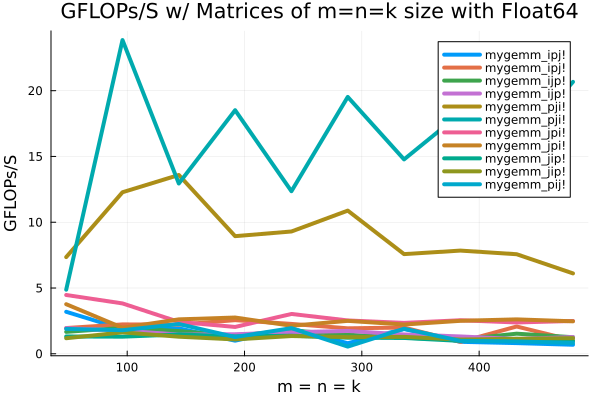

In [17]:
# What modules / packages do we depend on
using Random
using LinearAlgebra
using Printf
using Plots
default(linewidth=4) # Plots embelishments

# To ensure repeatability
Random.seed!(777)

# Don't let BLAS use lots of threads (since we are not multi-threaded yet!)
BLAS.set_num_threads(1)

# C := α * A * B' + β * C
refgemm!(C, A, B) = mul!(C, A, B', one(eltype(C)), one(eltype(C))) # to compare performance

# Algo 2.1: matrix times row vector (update rows of `C`) with inner dot product
#mygemm! = mygemm_ijp!

# Algo 2.2: matrix times row vector (update rows of `C`) with inner axpy
#mygemm! = mygemm_ipj!

# Algo 2.4: Rank one update (repeatedly update all elements of `C`) with outer product
# using axpy with columns of `A`
#mygemm! = mygemm_pji!

# Algo 2.5: matrix times column vector (update columns of `C`) with inner axpy || IGNORE
#mygemm! = mygemm_jpi!

# Algo 2.6: matrix times column vector (update columns of `C`) with inner dot product || IGNORE
#mygemm! = mygemm_jip!

# Requested algorithm
mygemm! = mygemm_pij!


num_reps = 3

# What precision numbers to use
# FloatType = Float32
FloatType = Float64

@printf("size |      reference      |           %s\n", mygemm!)
@printf("     |   seconds   GFLOPS  |   seconds   GFLOPS     err\n")

N = 48:48:480
best_perf = zeros(length(N))
# Size of square matrix to consider
for nmk in N
  i = Int(nmk / 48)
  n = m = k = nmk
  @printf("%4d |", nmk)

  gflops = 2 * m * n * k * 1e-09

  # Create the A, B, and C matrices with some random data
  A = rand(FloatType, m, k)
  B = rand(FloatType, k, n)
  C = rand(FloatType, m, n)

  # Make a copy of C for resetting data later
  C_old = copy(C)

  # The "truth", to check for correctness
  C_ref = C + A * B' # to check correctness, C_ref here will be your "truth"

  # Compute the reference timings
  best_time = typemax(FloatType)
  for iter = 1:num_reps
    # Reset C to the original data
    C .= C_old;
    run_time = @elapsed refgemm!(C, A, B);
    best_time = min(run_time, best_time)
  end
  # Make sure that we have the right answer!
  @assert C ≈ C_ref
  best_perf[i] = gflops / best_time

  # Print the reference implementation timing
  @printf("  %4.2e %8.2f  |", best_time, best_perf[i])

  # Compute the timing for mygemm! implementation
  best_time = typemax(FloatType)
  for iter = 1:num_reps
    # Reset C to the original data
    C .= C_old;
    run_time = @elapsed mygemm!(C, A, B);
    best_time = min(run_time, best_time)
  end
  best_perf[i] = gflops / best_time

  # Compute the error (difference between our implementation and the reference)
  err = norm(C - C_ref, Inf)

  # Print mygemm! implementations
  @printf("  %4.2e %8.2f   %.2e", best_time, best_perf[i], err)

  @printf("\n")
end

plot!(N, best_perf, xlabel = "m = n = k", ylabel = "GFLOPs/S", label = "$mygemm!", title = "GFLOPs/S w/ Matrices of m=n=k size with Float64")

size |      reference      |           mygemm_pij!
     |   seconds   GFLOPS  |   seconds   GFLOPS     err
  48 |  3.20e-06    69.12  |  8.64e-05     2.56   2.86e-06
  96 |  2.97e-05    59.58  |  1.02e-03     1.74   7.63e-06
 144 |  9.34e-05    63.94  |  4.08e-03     1.46   1.53e-05
 192 |  2.10e-04    67.25  |  9.57e-03     1.48   1.53e-05
 240 |  3.96e-04    69.80  |  2.02e-02     1.37   3.05e-05
 288 |  6.74e-04    70.93  |  3.36e-02     1.42   3.05e-05
 336 |  1.21e-03    62.53  |  4.73e-02     1.60   3.81e-05
 384 |  1.72e-03    65.78  |  1.27e-01     0.89   4.58e-05
 432 |  3.21e-03    50.25  |  1.14e-01     1.41   3.81e-05
 480 |  5.13e-03    43.16  |  2.82e-01     0.79   1.75e-04


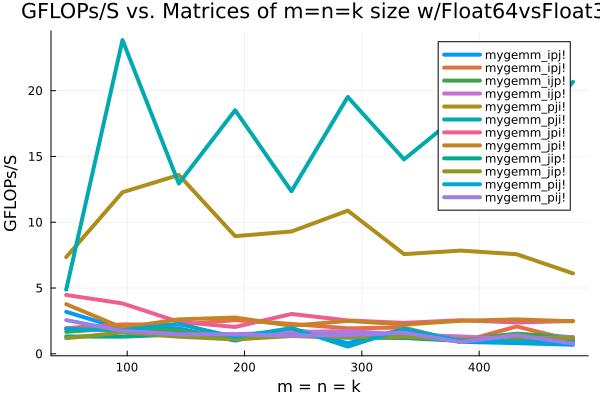

In [18]:
num_reps = 3

# What precision numbers to use
FloatType = Float32
#FloatType = Float64

@printf("size |      reference      |           %s\n", mygemm!)
@printf("     |   seconds   GFLOPS  |   seconds   GFLOPS     err\n")

N = 48:48:480
best_perf = zeros(length(N))
# Size of square matrix to consider
for nmk in N
  i = Int(nmk / 48)
  n = m = k = nmk
  @printf("%4d |", nmk)

  gflops = 2 * m * n * k * 1e-09

  # Create the A, B, and C matrices with some random data
  A = rand(FloatType, m, k)
  B = rand(FloatType, k, n)
  C = rand(FloatType, m, n)

  # Make a copy of C for resetting data later
  C_old = copy(C)

  # The "truth", to check for correctness
  C_ref = C + A * B' # to check correctness, C_ref here will be your "truth"

  # Compute the reference timings
  best_time = typemax(FloatType)
  for iter = 1:num_reps
    # Reset C to the original data
    C .= C_old;
    run_time = @elapsed refgemm!(C, A, B);
    best_time = min(run_time, best_time)
  end
  # Make sure that we have the right answer!
  @assert C ≈ C_ref
  best_perf[i] = gflops / best_time

  # Print the reference implementation timing
  @printf("  %4.2e %8.2f  |", best_time, best_perf[i])

  # Compute the timing for mygemm! implementation
  best_time = typemax(FloatType)
  for iter = 1:num_reps
    # Reset C to the original data
    C .= C_old;
    run_time = @elapsed mygemm!(C, A, B);
    best_time = min(run_time, best_time)
  end
  best_perf[i] = gflops / best_time

  # Compute the error (difference between our implementation and the reference)
  err = norm(C - C_ref, Inf)

  # Print mygemm! implementations
  @printf("  %4.2e %8.2f   %.2e", best_time, best_perf[i], err)

  @printf("\n")
end

plot!(N, best_perf, xlabel = "m = n = k", ylabel = "GFLOPs/S", label = "$mygemm!", title = "GFLOPs/S vs. Matrices of m=n=k size w/Float64vsFloat32")

In [21]:
import Pkg;
Pkg.add("NBInclude")
Pkg.add("Random")
Pkg.add("LinearAlgebra")
Pkg.add("Printf")
Pkg.add("Plots")

using NBInclude
nbexport("assignment2.jl", "assignment2.ipynb")

   Resolving package versions...
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\littl\.julia\environments\v1.11\Manifest.toml`
